# Chapter 5: Autoregressive and Moving Average Models (AR & MA)
- We use a classic, real-world dataset of monthly airline passengers to explore non-stationarity, deterministic trends, and variance changes.
## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
import yfinance as yf



##  2. Load Dataset (Air Passengers)


Loading real airline passengers dataset...


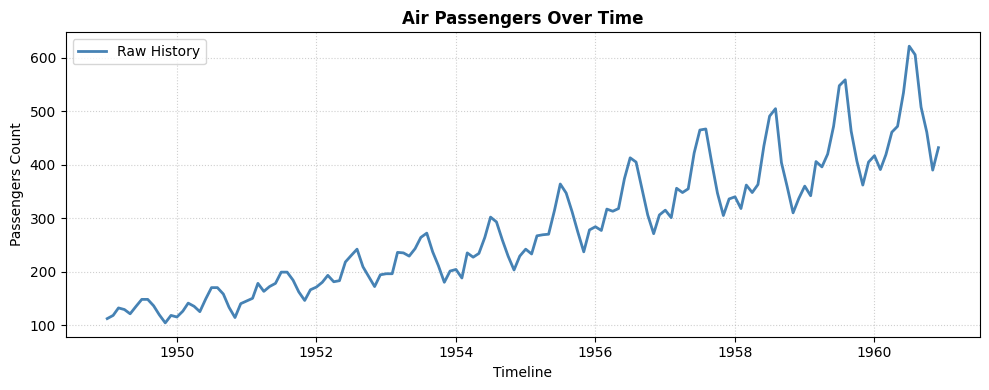

In [2]:
print("Loading real airline passengers dataset...")
df = pd.read_csv("airline-passengers.csv")

# Clean column headers and enforce uniform schema
df.columns = ["Month", "Passengers"]
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

ts = df["Passengers"]

plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values, color="steelblue", linewidth=2, label="Raw History")
plt.title("Air Passengers Over Time", fontsize=12, fontweight="bold")
plt.xlabel("Timeline")
plt.ylabel("Passengers Count")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 3. ACF Analysis on raw data

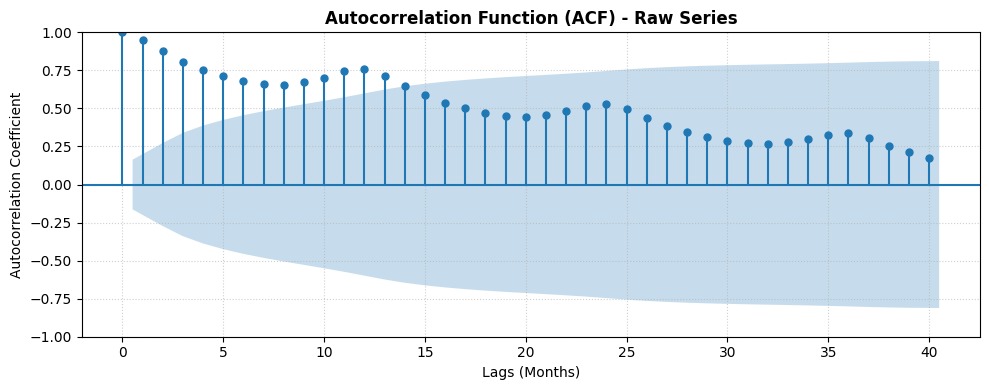

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(ts, ax=ax, lags=40)
ax.set_title("Autocorrelation Function (ACF) - Raw Series", fontsize=12, fontweight="bold")
ax.set_xlabel("Lags (Months)")
ax.set_ylabel("Autocorrelation Coefficient")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Stationarity Check (ADF Test)
Before building classical models, we use the Augmented Dickey-Fuller (ADF) test to evaluate if the raw time series exhibits a constant mean and variance.

In [4]:

print("\n--- Stationarity Analysis on Raw Series ---")
result = adfuller(ts)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")


--- Stationarity Analysis on Raw Series ---
ADF Statistic: 0.8154
p-value: 0.9919



## 5. Differencing (Trend and Seasonal Removal)
Because the series displays both a linear trend and a 12-month seasonal variance, we apply double-differencing to isolate the stationary components.


Applying trend and seasonal differencing...


<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
C:\Users\oadsa\AppData\Local\Temp\ipykernel_10632\3936080064.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta^2$ Passengers")


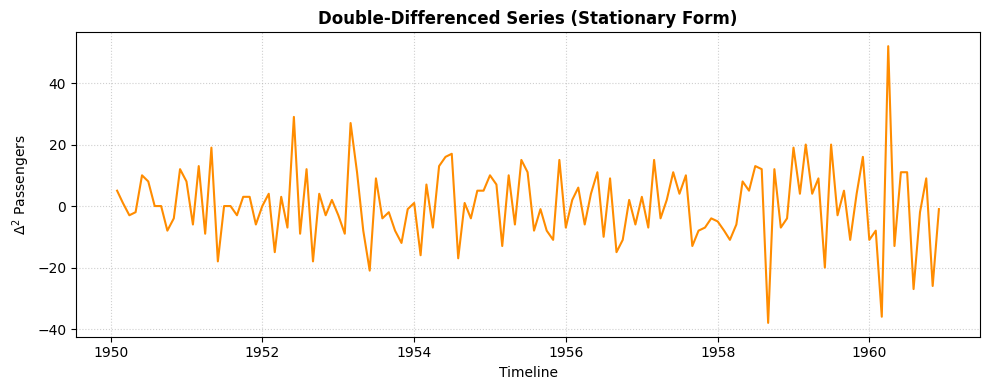


--- Stationarity Analysis on Double-Differenced Series ---
ADF Statistic (Double Diff): -15.5956
p-value (Double Diff): 1.8565e-28
Conclusion: The double-differenced series is stationary (p < 0.05).


In [5]:
print("\nApplying trend and seasonal differencing...")
# Step 1: Remove linear trend (first difference)
ts_diff = ts.diff()

# Step 2: Remove 12-month seasonality (seasonal difference)
ts_double_diff = ts_diff.diff(12).dropna()

plt.figure(figsize=(10, 4))
plt.plot(ts_double_diff.index, ts_double_diff.values, color="darkorange", linewidth=1.5)
plt.title("Double-Differenced Series (Stationary Form)", fontsize=12, fontweight="bold")
plt.xlabel("Timeline")
plt.ylabel("$\Delta^2$ Passengers")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

print("\n--- Stationarity Analysis on Double-Differenced Series ---")
result_double_diff = adfuller(ts_double_diff)
print(f"ADF Statistic (Double Diff): {result_double_diff[0]:.4f}")
print(f"p-value (Double Diff): {result_double_diff[1]:.4e}")

if result_double_diff[1] < 0.05:
    print("Conclusion: The double-differenced series is stationary (p < 0.05).")
else:
    print("Conclusion: The series remains non-stationary.")

## 6. ACF & PACF Analysis
We plot the Autocorrelation and Partial Autocorrelation Functions of our stationary series to visually determine optimal model orders (p, q).

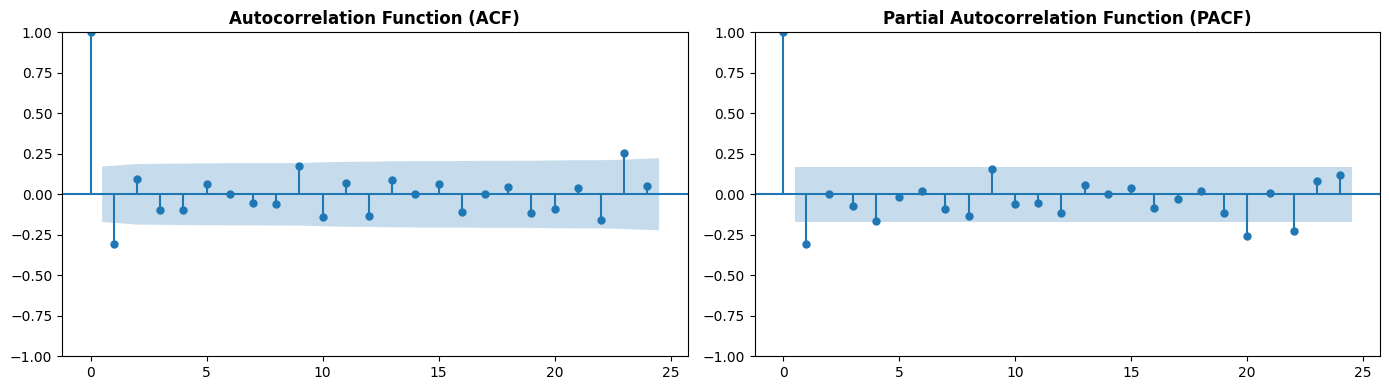

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_double_diff, ax=ax[0], lags=24)
plot_pacf(ts_double_diff, ax=ax[1], lags=24)
ax[0].set_title("Autocorrelation Function (ACF)", fontweight="bold")
ax[1].set_title("Partial Autocorrelation Function (PACF)", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Autoregressive (AR) Modeling & Forecast Inversion
We fit an AR(2) model on the transformed data. 


Fitting Autoregressive model to stationary double-differenced data...
                            AutoReg Model Results                             
Dep. Variable:             Passengers   No. Observations:                  131
Model:                     AutoReg(2)   Log Likelihood                -501.260
Method:               Conditional MLE   S.D. of innovations             11.785
Date:                Sun, 17 May 2026   AIC                           1010.520
Time:                        13:29:10   BIC                           1021.959
Sample:                    04-01-1950   HQIC                          1015.168
                         - 12-01-1960                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1883      1.038      0.181      0.856      -1.847       2.224
Passengers.L1    -0.3108      0.088     -3.522     

c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\oadsa\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


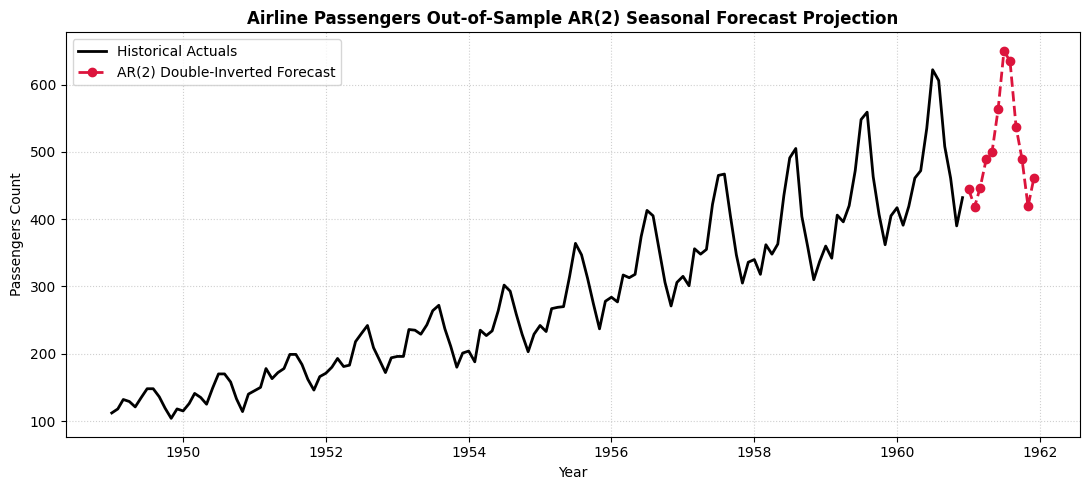

In [7]:

print("\nFitting Autoregressive model to stationary double-differenced data...")
model_ar = AutoReg(ts_double_diff, lags=2).fit()
print(model_ar.summary())

# Determine the out-of-sample forecast range
forecast_steps = 12
start_date = ts_double_diff.index[-1] + pd.DateOffset(months=1)
end_date = ts_double_diff.index[-1] + pd.DateOffset(months=forecast_steps)

# Generate out-of-sample predictions on the differenced scale
pred_double_diff = model_ar.predict(start=start_date, end=end_date)

# Recursive Inversion Loop
history = list(ts.values)
inverted_forecast = []

for i in range(forecast_steps):
    w = pred_double_diff.iloc[i]
    y_prev1 = history[-1]       # 1 month ago
    y_prev12 = history[-12]     # 12 months ago
    y_prev13 = history[-13]     # 13 months ago

    # Reconstruct the true scale value
    y_t = w + y_prev1 + y_prev12 - y_prev13

    inverted_forecast.append(y_t)
    history.append(y_t)

# Map values to a clean DatetimeIndex
forecast_index = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1),
    periods=forecast_steps,
    freq="MS"
)
forecast_series = pd.Series(inverted_forecast, index=forecast_index)

# Plot history along with the projected seasonal forecast
plt.figure(figsize=(11, 5))
plt.plot(ts.index, ts.values, label="Historical Actuals", color="black", linewidth=2)
plt.plot(forecast_series.index, forecast_series.values, label="AR(2) Double-Inverted Forecast",
         color="crimson", linestyle="--", marker="o", linewidth=2)
plt.title("Airline Passengers Out-of-Sample AR(2) Seasonal Forecast Projection", fontsize=12, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Passengers Count")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 8. Moving Average (MA) Process Simulation
We simulate an MA(1) system to demonstrate how independent random shocks preserve short-term memory before cutting off completely.

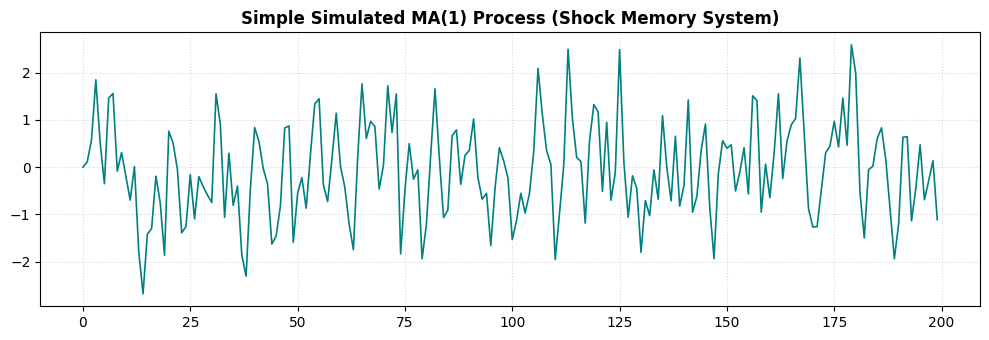

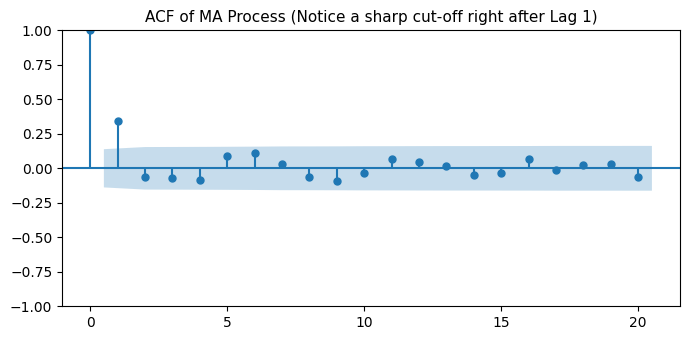

In [8]:
np.random.seed(42)
n_sim = 200
noise_sim = np.random.normal(0, 1, n_sim)
ma_series = np.zeros(n_sim)

# Construct MA(1) process: Y_t = e_t + theta * e_{t-1}
for i in range(1, n_sim):
    ma_series[i] = noise_sim[i] + 0.5 * noise_sim[i-1]

plt.figure(figsize=(10, 3.5))
plt.plot(ma_series, color="teal", linewidth=1.2)
plt.title("Simple Simulated MA(1) Process (Shock Memory System)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
plot_acf(ma_series, lags=20, ax=ax)
plt.title("ACF of MA Process (Notice a sharp cut-off right after Lag 1)", fontsize=11)
plt.tight_layout()
plt.show()

## 9. Random Walk Simulation & Real Stock Comparison
To build intuition around pure unit root behavior, we compare a simulated mathematical random walk against real financial asset data.

<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
C:\Users\oadsa\AppData\Local\Temp\ipykernel_10632\3428412241.py:8: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Random Walk Simulation ($Y_t = Y_{t-1} + \epsilon_t$)", fontsize=12, fontweight="bold")


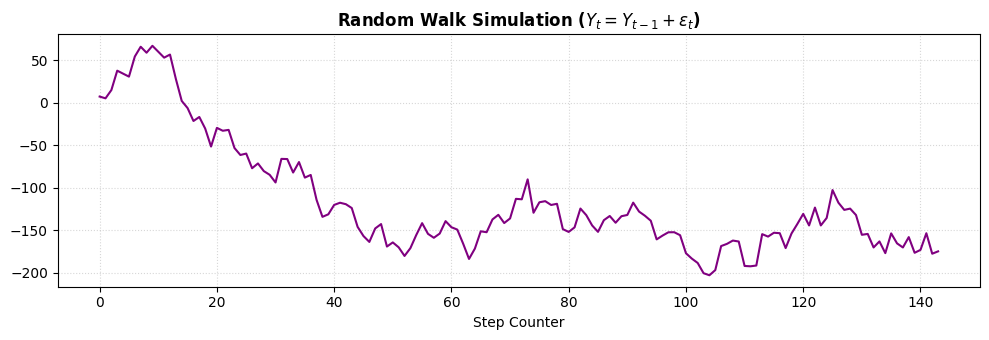

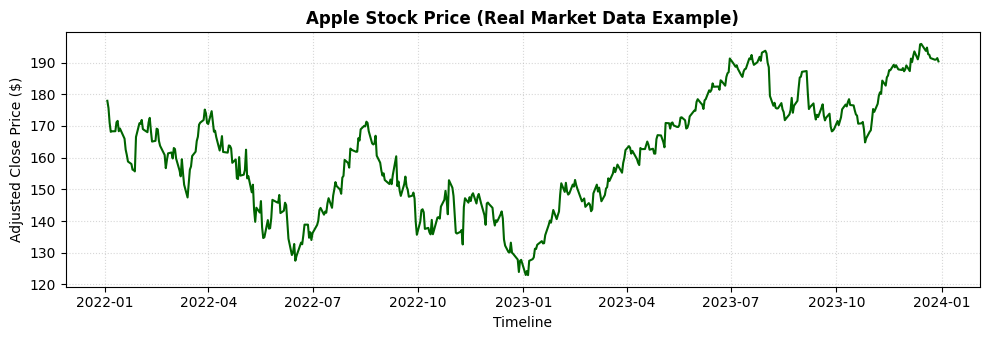

In [9]:
np.random.seed(42)
n = len(ts)
noise = np.random.normal(0, 15, n)
random_walk = np.cumsum(noise)

plt.figure(figsize=(10, 3.5))
plt.plot(random_walk, color="purple", linewidth=1.5)
plt.title("Random Walk Simulation ($Y_t = Y_{t-1} + \epsilon_t$)", fontsize=12, fontweight="bold")
plt.xlabel("Step Counter")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print("\nDownloading Apple stock data from Yahoo Finance...")
data = yf.download("AAPL", start="2022-01-01", end="2024-01-01", progress=False)

if isinstance(data.columns, pd.MultiIndex):
    stock = data["Close"].squeeze()
else:
    stock = data["Close"]

plt.figure(figsize=(10, 3.5))
plt.plot(stock.index, stock.values, color="darkgreen", linewidth=1.5)
plt.title("Apple Stock Price (Real Market Data Example)", fontsize=12, fontweight="bold")
plt.xlabel("Timeline")
plt.ylabel("Adjusted Close Price ($)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

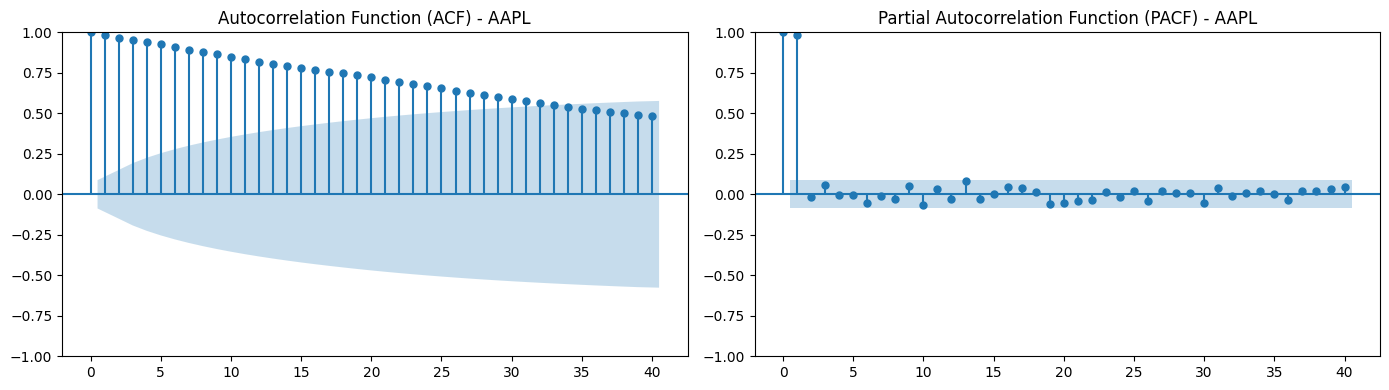

In [10]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF plot
plot_acf(stock.dropna(), lags=40, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF) - AAPL")

# PACF plot
plot_pacf(stock.dropna(), lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF) - AAPL")

plt.tight_layout()
plt.show()

## 10. ARMA Simulation & Summary Reference
We evaluate an ARMA(1,1) model structure that combines structural momentum with localized errors.

<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
C:\Users\oadsa\AppData\Local\Temp\ipykernel_10632\2203147955.py:17: SyntaxWarning: invalid escape sequence '\e'
  "Driven By": ["Past values ($y_{t-p}$)", "Past shocks ($\epsilon_{t-q}$)", "Last position + white noise", "Both historical values + shocks"],


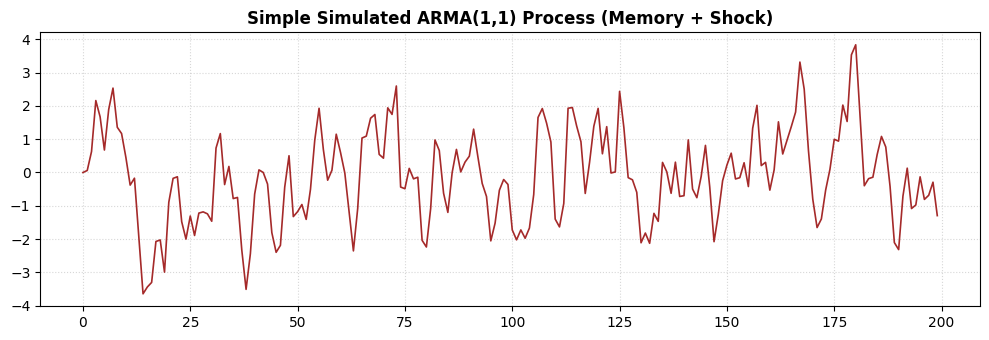


               Model                       Driven By             Memory Type
AR (Autoregressive)         Past values ($y_{t-p}$)     Structural Systemic
MA (Moving Average)  Past shocks ($\epsilon_{t-q}$) Temporary Noise Impulse
        Random Walk     Last position + white noise      Infinite Unit Root
               ARMA Both historical values + shocks     Mixed Latency Space


In [11]:

arma_series = np.zeros(n_sim)
for t in range(1, n_sim):
    ar_part = 0.6 * arma_series[t-1]
    ma_part = 0.4 * noise_sim[t-1]
    arma_series[t] = ar_part + ma_part + noise_sim[t]

plt.figure(figsize=(10, 3.5))
plt.plot(arma_series, color="brown", linewidth=1.2)
plt.title("Simple Simulated ARMA(1,1) Process (Memory + Shock)", fontsize=12, fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

# Core Concept Reference Summary
table = pd.DataFrame({
    "Model": ["AR (Autoregressive)", "MA (Moving Average)", "Random Walk", "ARMA"],
    "Driven By": ["Past values ($y_{t-p}$)", "Past shocks ($\epsilon_{t-q}$)", "Last position + white noise", "Both historical values + shocks"],
    "Memory Type": ["Structural Systemic", "Temporary Noise Impulse", "Infinite Unit Root", "Mixed Latency Space"]
})
print("\n", table.to_string(index=False))

# 11. Core Structural Synthesis 
To conclude the chapter, we normalize and standardize our real data alongside our simulated processes to directly compare variations in signal structures.
- Strip leading missing values from the first difference to avoid NaN leakage

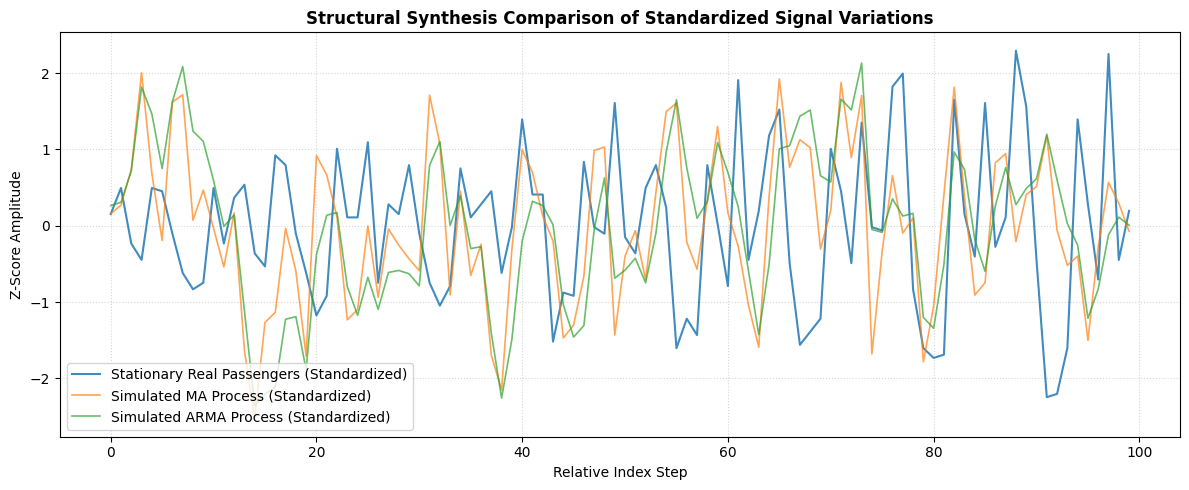

In [12]:

ts_raw_slice = ts_diff.dropna().iloc[:100].values
ma_slice = ma_series[:100]
arma_slice = arma_series[:100]

# Compute standardized Z-scores to align varying scales
ts_plot = (ts_raw_slice - np.mean(ts_raw_slice)) / np.std(ts_raw_slice)
ma_plot = (ma_slice - np.mean(ma_slice)) / np.std(ma_slice)
arma_plot = (arma_slice - np.mean(arma_slice)) / np.std(arma_slice)

plt.figure(figsize=(12, 5))
plt.plot(ts_plot, label="Stationary Real Passengers (Standardized)", alpha=0.85, linewidth=1.5)
plt.plot(ma_plot, label="Simulated MA Process (Standardized)", alpha=0.7, linewidth=1.2)
plt.plot(arma_plot, label="Simulated ARMA Process (Standardized)", alpha=0.7, linewidth=1.2)
plt.title("Structural Synthesis Comparison of Standardized Signal Variations", fontsize=12, fontweight="bold")
plt.xlabel("Relative Index Step")
plt.ylabel("Z-Score Amplitude")
plt.legend(loc="lower left")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()